# 3 · Points, cells & vector fields

`scatter` / `grid_points` / `grid_cells` (points & polygons) and `quiver` / `barbs` / `streamplot` (vector fields).

In [1]:
%matplotlib inline
from pathlib import Path

# Resolve the repo root so the bundled sample data is found whether this runs
# from docs/examples/ (mkdocs) or the repository root.
ROOT = Path.cwd()
while not (ROOT / "examples" / "data" / "acc4000.tif").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
RASTER = str(ROOT / "examples" / "data" / "acc4000.tif")
POINTS = str(ROOT / "tests" / "data" / "points.geojson")
print("data root:", ROOT)

data root: C:\gdrive\algorithms\Visualization\Digital-Earth


In [2]:
import numpy as np
from pyramids.dataset import Dataset
from pyramids.feature import FeatureCollection
from digitalearth.scene import Map

ds = Dataset.read_file(RASTER)

2026-05-28 00:30:47 | INFO | pyramids.base.config | Logging is configured.


## grid_points — raster cell centres coloured by value

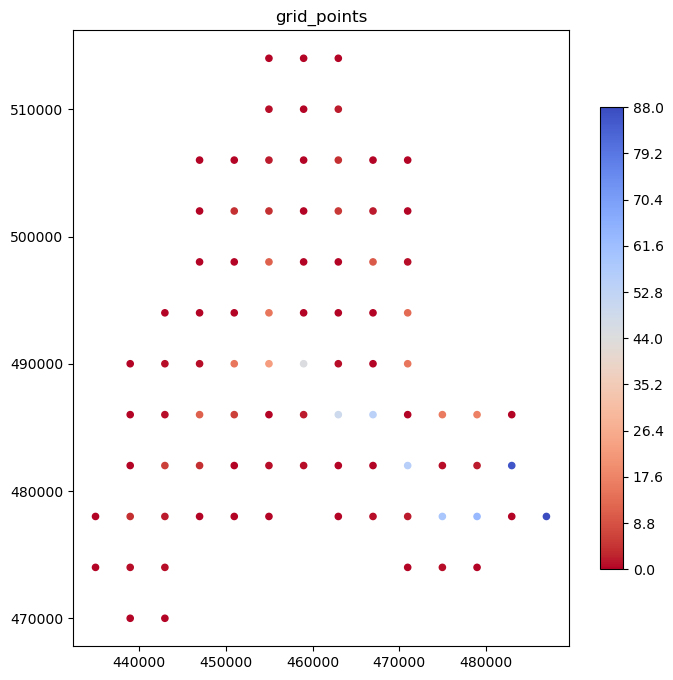

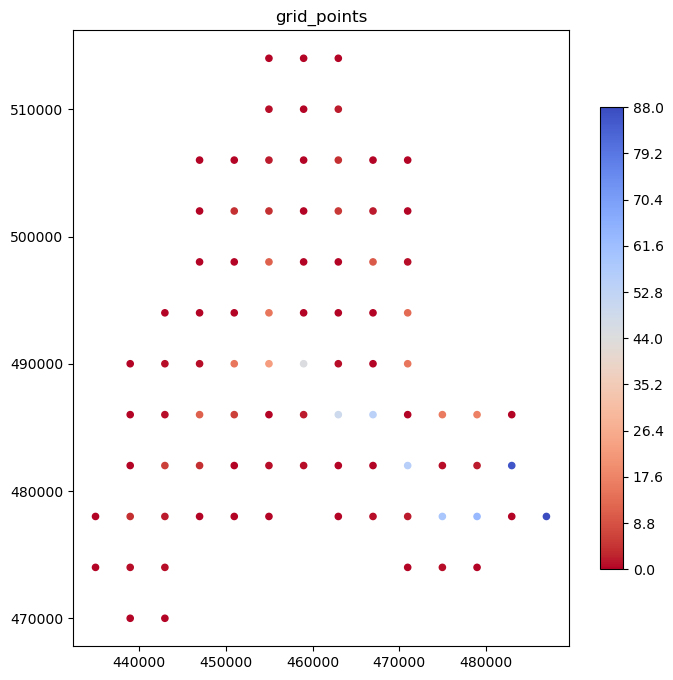

In [3]:
m = Map(crs=ds.epsg)
m.grid_points(ds)
m.set_title('grid_points')
m.fig

## grid_cells — one coloured polygon per cell

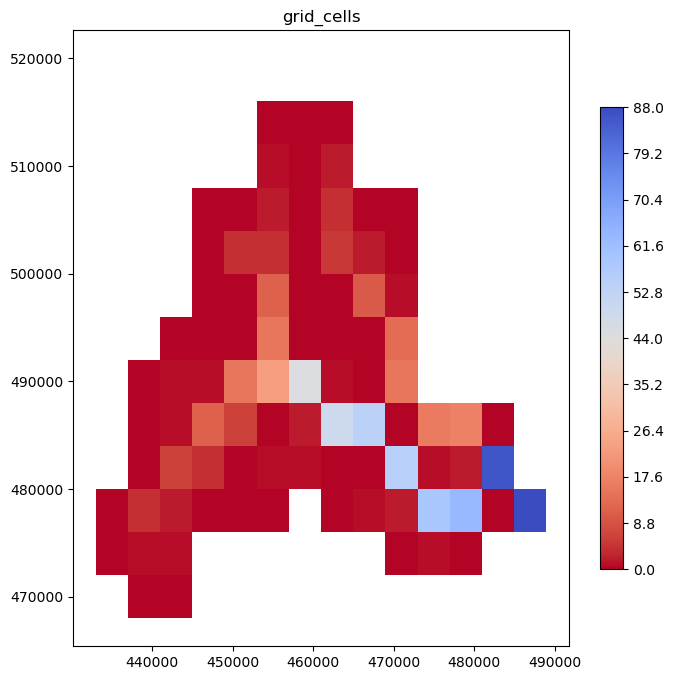

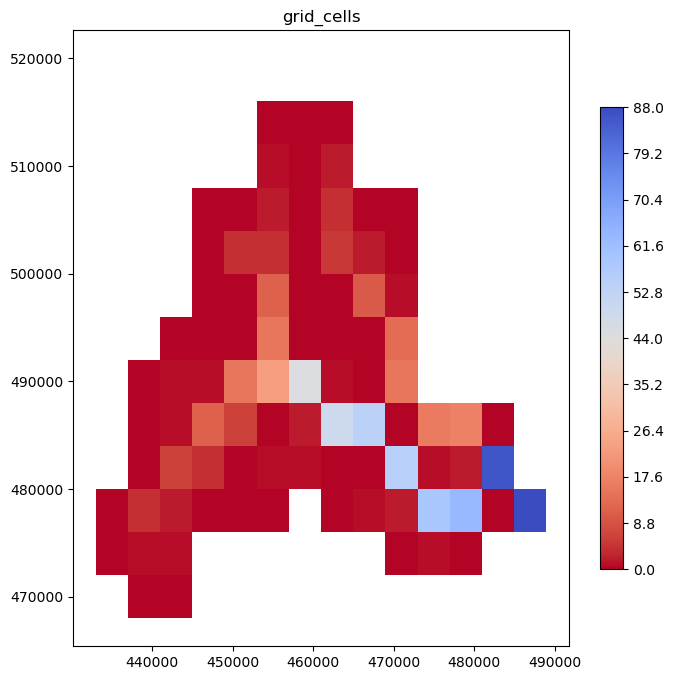

In [4]:
m = Map(crs=ds.epsg)
m.grid_cells(ds)
m.set_title('grid_cells')
m.fig

## scatter — a FeatureCollection of points

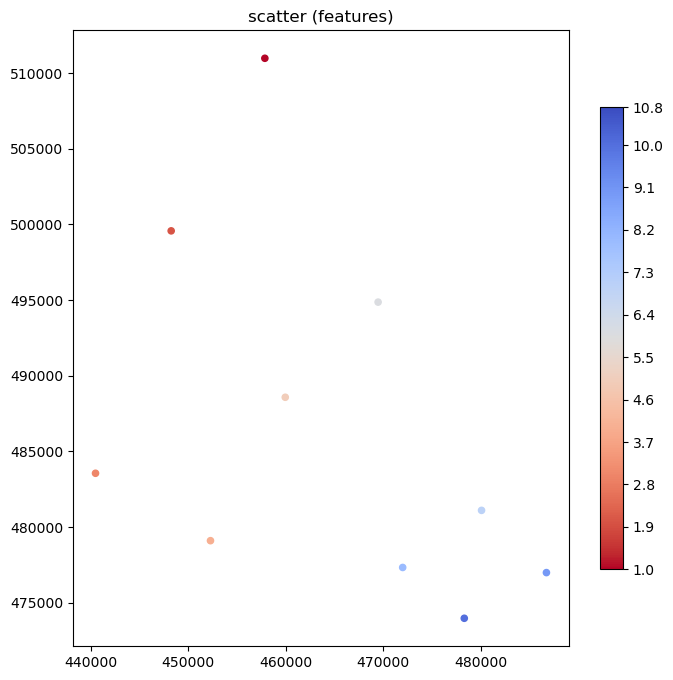

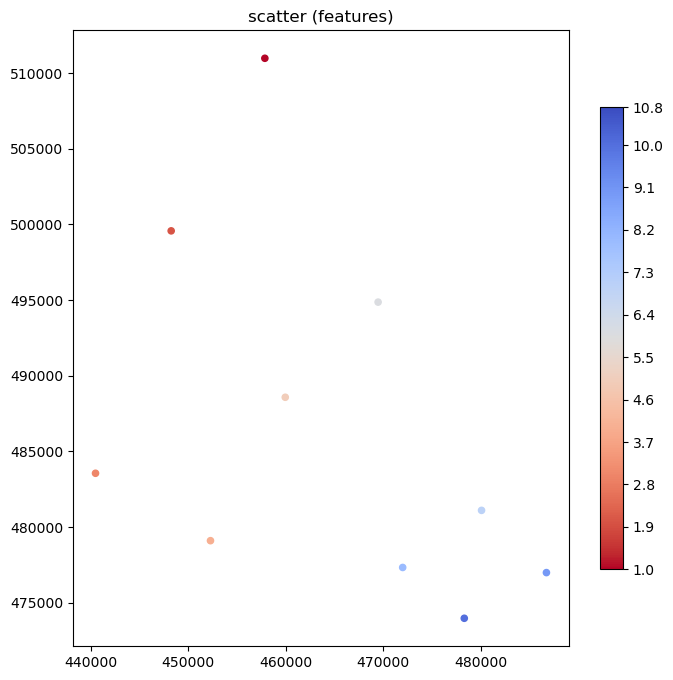

In [5]:
fc = FeatureCollection.read_file(POINTS)
m = Map(crs=fc.epsg)
m.scatter(fc)
m.set_title('scatter (features)')
m.fig

## Vector field — quiver / barbs / streamplot from two rasters (u, v)

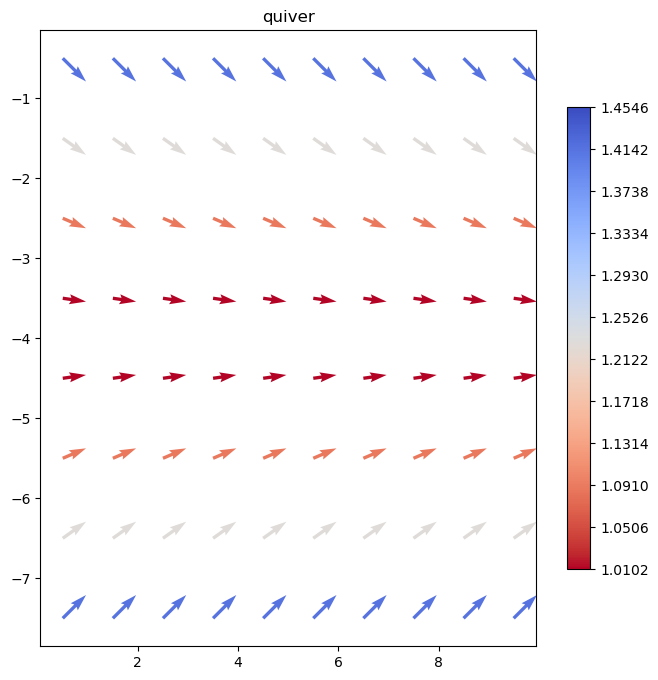

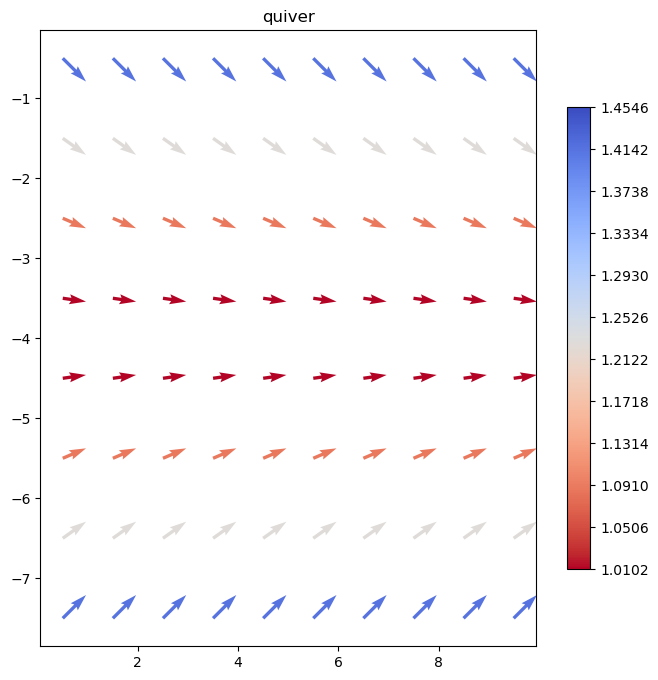

In [6]:
ny, nx = 8, 10
u = np.ones((ny, nx), 'float32')
v = (np.linspace(-1, 1, ny, dtype='float32')[:, None] * np.ones((1, nx), 'float32'))
geo = (0.0, 1.0, 0.0, 0.0, 0.0, 1.0)
u_ds = Dataset.create_from_array(arr=u, geo=geo, epsg=4326)
v_ds = Dataset.create_from_array(arr=v, geo=geo, epsg=4326)
m = Map(crs=4326)
m.quiver(u_ds, v_ds)
m.set_title('quiver')
m.fig

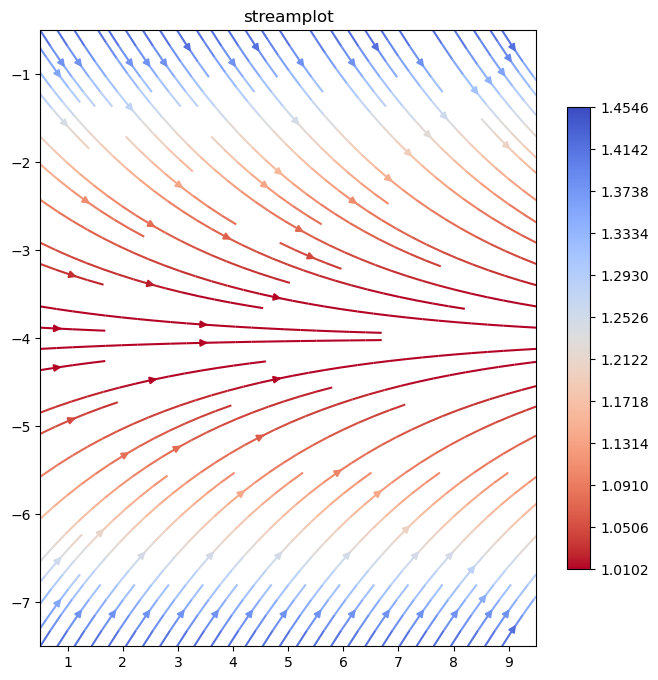

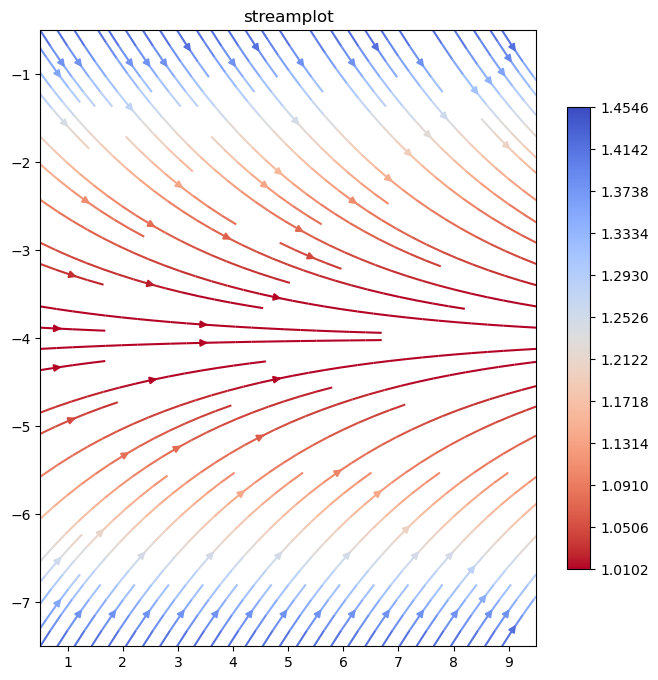

In [7]:
m = Map(crs=4326)
m.streamplot(u_ds, v_ds)
m.set_title('streamplot')
m.fig